<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">             <tr>
                <td  style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>Armin Ghasemi</b><br><br>810100198</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> ML </b><br><br>Final_Project</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>  </b><br><br></i></font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
           </tr>
        </table>
    </div>
</div>

# 🔍 Unsupervised Audio Clustering & Pattern Analysis
### Comparative Study of K-Means, DBSCAN, and Agglomerative Clustering

> **University:** University of Tehran
> **Course:** Machine Learning
> **Project:** Final Capstone Project - Part B
> **Techniques:** Feature Engineering, PCA, Outlier Imputation, Clustering Algorithms

---

## 🎯 Project Objective
This notebook explores the latent structures within the extracted audio feature vectors (MFCCs, Pitch, ZCR). The primary goal is to determine if voice samples naturally segregate into distinct clusters (e.g., by Gender or Speaker ID) without utilizing explicit labels during the learning process.

## ⚙️ Technical Approach & Pipeline

### 1. Advanced Data Preprocessing
Before applying clustering algorithms, we ensure data quality through a rigorous pipeline:
* **Class Balancing:** Downsampling the majority class (Male) to match the minority class (Female) to prevent density bias in clustering.
* **Outlier Handling:** Detecting outliers using the **IQR method** and imputing them using **Linear Regression** (instead of simple deletion) to preserve data integrity.
* **Feature Selection:** Removing low-variance features using `VarianceThreshold`.
* **Standardization:** Normalizing features using `StandardScaler`.

### 2. Dimensionality Reduction
* **PCA (Principal Component Analysis):** Reducing the feature space to 2 dimensions for visualization and noise reduction, retaining **85%+** of the explained variance.

### 3. Clustering Algorithms & Evaluation
We implement and compare three distinct clustering paradigms:
* **K-Means:** Using the **Elbow Method** and **Silhouette Analysis** to find the optimal $K$.
* **DBSCAN:** A density-based approach using **K-Distance Graph (KneeLocator)** to automatically tune `eps`.
* **Hierarchical (Agglomerative):** Using Ward's linkage and **Dendrograms** to analyze the merging hierarchy.

---

### Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import clustering and evaluation metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from kneed import KneeLocator

# ==========================================
# Global Path Configuration
# ==========================================
# Define the base directory (current working directory)
BASE_DIR = os.getcwd()

# Define the directory containing feature CSV files
# This points to: ./data/feature_stores/
DATA_DIR = os.path.join(BASE_DIR, "data", "feature_stores")

# Define the input filename
# WARNING: Ensure this matches the actual name of your aggregated CSV file
INPUT_FILENAME = "clustering_dataset.csv" 

# Construct the full absolute path to the dataset
INPUT_FILE_PATH = os.path.join(DATA_DIR, INPUT_FILENAME)

print(f"Configuration set. Looking for dataset at: {INPUT_FILE_PATH}")

### Data loading and preprocessing 

In [ ]:
# --- 1. Load Dataset ---
# Check if the file exists before trying to read it
if os.path.exists(INPUT_FILE_PATH):
    df = pd.read_csv(INPUT_FILE_PATH)
    print(f"Successfully loaded dataset. Shape: {df.shape}")
else:
    # Stop execution if file is missing to prevent obscure errors later
    raise FileNotFoundError(f"File not found at: {INPUT_FILE_PATH}. Please check 'data/feature_stores' folder.")

# --- 2. Initial Cleanup ---
# Drop the first column (usually 'filename' or index from previous save)
if df.shape[1] > 0:
    df.drop(df.columns[0], axis=1, inplace=True)

# --- 3. Class Balancing (Undersampling) ---
# Assuming the last column is the label (0: Female, 1: Male)
num_females = df[df.iloc[:, -1] == 0].shape[0] 
num_males = df[df.iloc[:, -1] == 1].shape[0]   

print(f"Original counts - Female: {num_females}, Male: {num_males}")

# Undersample the majority class (Male) to match Female count
df_males_sampled = df[df.iloc[:, -1] == 1].sample(n=num_females, random_state=42)
df_females = df[df.iloc[:, -1] == 0] 

# Concatenate and shuffle the dataset
df = pd.concat([df_males_sampled, df_females])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Balanced dataset shape: {df.shape}")

# --- 4. Data Quality Check ---

# Handle duplicates
num_duplicates = df.duplicated().sum()
if num_duplicates > 0:
    print(f"{num_duplicates} duplicate lines found and deleted.")
    df.drop_duplicates(inplace=True)

# Handle missing values
missing_values = df.isnull().sum()
if missing_values.sum() > 0:
    print("Missing data found in the following columns:")
    print(missing_values[missing_values > 0])
    df.dropna(inplace=True)

# --- 5. Prepare for Unsupervised Learning ---
# Drop the label column ("Gender") since clustering is unsupervised
# Note: Ensure the column name matches your CSV header (e.g., "Gender", "label", or "male")
if "Gender" in df.columns:
    df = df.drop(columns=["Gender"])
else:
    print("Warning: 'Gender' column not found. Dropping the last column as label.")
    df = df.iloc[:, :-1]

# Display the first few rows of the cleaned dataframe
df.head()

,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,...,MFCC_13,MFCC_14,MFCC_15,MFCC_16,MFCC_17,MFCC_18,MFCC_19,MFCC_20,F0,ZCR
0,-204.79002,167.773540,-58.762400,55.283830,-8.432484,-12.494717,-4.864219,-23.670970,15.936469,-29.124222,...,-22.345112,-5.210696,-26.932735,-18.427925,3.017614,-19.243973,-2.963802,-3.191291,178.769272,0.047791
1,-247.46280,192.591140,-58.529133,18.164148,-0.170012,4.535144,-11.914583,-19.879827,7.448323,-9.779433,...,-24.674770,2.542556,-7.412078,-13.461781,-7.085751,-4.305414,-2.608965,1.940107,160.792582,0.044128
2,-297.57020,152.075780,29.413137,50.575996,-35.649100,-35.529870,-2.318813,-32.488823,-16.262325,-3.495658,...,4.900009,-6.134339,-11.671482,2.407791,-7.411122,-9.810541,-0.688800,-9.850800,296.993671,0.053558
3,-311.08566,141.721360,20.564354,53.421090,8.221550,-40.775470,-16.817700,-8.767285,-15.623123,-9.452795,...,-3.349215,-5.278918,-9.791001,-7.493893,-13.309488,-9.181157,-1.894670,-10.106483,337.739690,0.035645
4,-192.69823,136.460360,-66.735120,32.252274,-44.280212,-41.645454,-5.748497,-26.411243,4.809887,-7.406499,...,-7.037510,-8.221858,-16.146908,-0.385008,-5.351375,-9.763346,0.008369,-9.150161,348.014495,0.075470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2355,-111.68323,164.274290,-72.602690,77.579590,-30.654010,11.724138,1.520056,-6.814704,23.330538,-16.214294,...,0.572801,8.950277,-1.271226,7.210412,1.084622,2.539948,-0.277436,-5.612590,0.000000,0.103760
2356,-234.40115,140.953220,-41.636463,85.239395,-23.222610,2.377231,-4.659464,-34.197044,1.992987,-4.684725,...,-7.250157,2.918335,-6.679209,-0.182744,-4.280344,-5.698249,-11.824001,-8.950109,83.985594,0.139008
2357,-267.18060,151.211100,13.502986,40.707287,-8.538734,-3.912162,-1.552251,-23.893368,-1.403188,-8.818091,...,-12.084392,9.746341,-2.323198,-7.728210,5.913013,-12.765455,-2.939900,3.891697,224.867110,0.044891
2358,-307.32660,127.966774,14.921621,41.698510,4.922905,-17.078133,-23.830696,-20.798160,3.340485,-12.796722,...,-5.303265,3.903328,-1.582679,-4.617274,1.206576,-7.869531,-9.362453,-4.250425,323.444979,0.058411


### Finding and handling outliers

In [54]:
def count_outliers(data):
    outlier_counts = {}
    for column in data.columns:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_counts[column] = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()
    return outlier_counts

outliers_indices = []
for column in df.columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    column_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)].index
    outliers_indices.extend(column_outliers)

outliers_indices = list(set(outliers_indices))

df_cleaned = df.copy()
for column in df.columns:
    column_outliers = df_cleaned.loc[outliers_indices, column]
    if not column_outliers.empty:
        other_columns = [col for col in df.columns if col != column]
        model = LinearRegression()
        non_outliers = df_cleaned.drop(index=outliers_indices)
        model.fit(non_outliers[other_columns], non_outliers[column])
        predicted_values = model.predict(df_cleaned.loc[outliers_indices, other_columns])
        df_cleaned.loc[outliers_indices, column] = predicted_values

outliers_before = count_outliers(df)
outliers_after = count_outliers(df_cleaned)

outliers_summary = pd.DataFrame({
    'Column': df.columns,
    'Outliers Before': [outliers_before[col] for col in df.columns],
    'Outliers After': [outliers_after[col] for col in df.columns]
})
outliers_summary.style.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
])


,Column,Outliers Before,Outliers After
0,MFCC_1,49,14
1,MFCC_2,14,19
2,MFCC_3,19,20
3,MFCC_4,19,18
4,MFCC_5,17,17
5,MFCC_6,8,8
6,MFCC_7,16,16
7,MFCC_8,36,35
8,MFCC_9,15,15
9,MFCC_10,35,34


### Standardization 

In [55]:
scaler_standard = StandardScaler()


df_standardized = pd.DataFrame(scaler_standard.fit_transform(df_cleaned), columns=df_cleaned.columns)


## feature selection

### Variance Threshold

In [56]:


selector = VarianceThreshold(threshold=0.1)
selector.fit(df)
selected_features = df.columns[selector.get_support()]
df = df[selected_features] 

selected_features

Index(['MFCC_1', 'MFCC_2', 'MFCC_3', 'MFCC_4', 'MFCC_5', 'MFCC_6', 'MFCC_7',
       'MFCC_8', 'MFCC_9', 'MFCC_10', 'MFCC_11', 'MFCC_12', 'MFCC_13',
       'MFCC_14', 'MFCC_15', 'MFCC_16', 'MFCC_17', 'MFCC_18', 'MFCC_19',
       'MFCC_20', 'F0'],
      dtype='object')

## feature conditioning

### PCA 

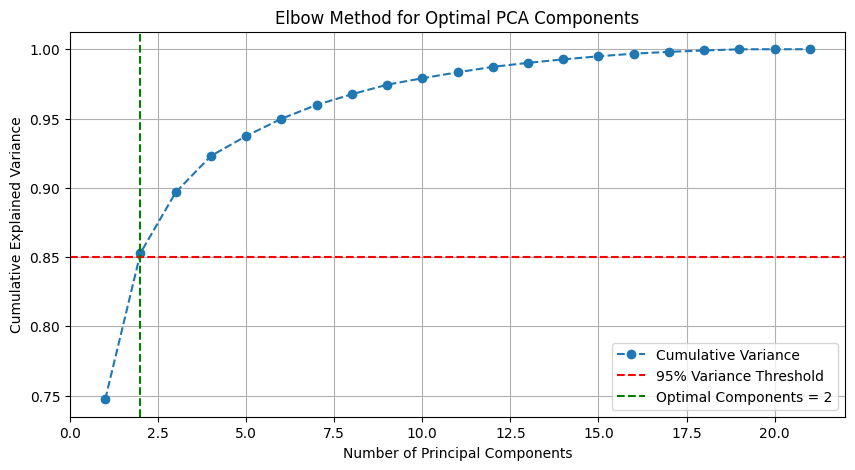

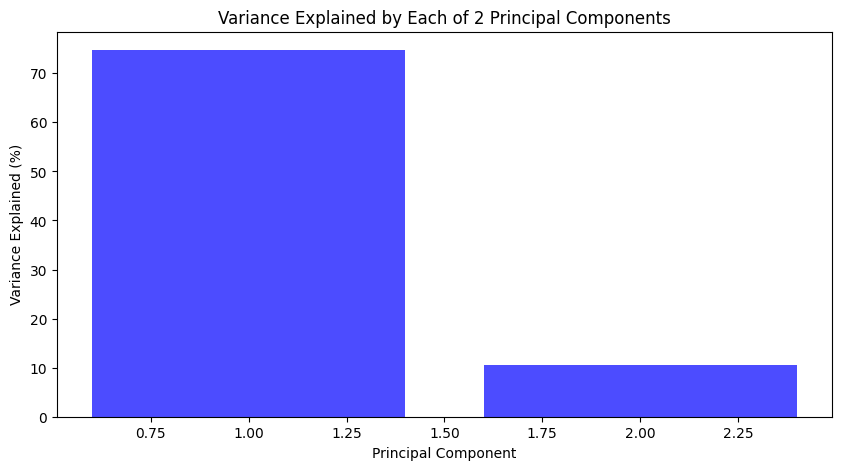


Optimal number of components: 2

Explained Variance of Selected Principal Components:
  Principal Component  Explained Variance (%)
0                 PC1                   74.74
1                 PC2                   10.55


In [57]:

pca = PCA()
df_pca = pca.fit_transform(df)

explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

optimal_components = np.argmax(explained_variance_ratio >= 0.85) + 1


plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', label="Cumulative Variance")
plt.axhline(y=0.85, color='r', linestyle='--', label="95% Variance Threshold")
plt.axvline(x=optimal_components, color='g', linestyle='--', label=f"Optimal Components = {optimal_components}")
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Elbow Method for Optimal PCA Components')
plt.legend()
plt.grid()
plt.show()


pca = PCA(n_components=optimal_components)
df_pca = pca.fit_transform(df)

plt.figure(figsize=(10, 5))
plt.bar(range(1, optimal_components + 1), pca.explained_variance_ratio_ * 100, alpha=0.7, color="b")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.title(f"Variance Explained by Each of {optimal_components} Principal Components")
plt.show()

explained_variance_df = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(optimal_components)],
    "Explained Variance (%)": np.round(pca.explained_variance_ratio_ * 100, 2)
})
print("\nOptimal number of components:", optimal_components)
print("\nExplained Variance of Selected Principal Components:")
print(explained_variance_df)


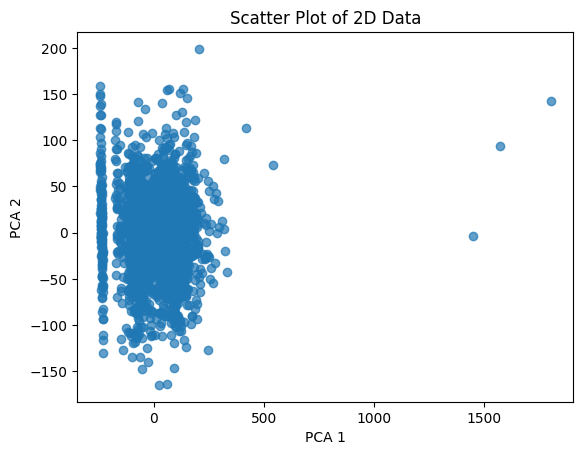

In [58]:
data = df_pca
plt.scatter(data[:, 0], data[:, 1], alpha=0.7)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Scatter Plot of 2D Data")
plt.show()

### k means

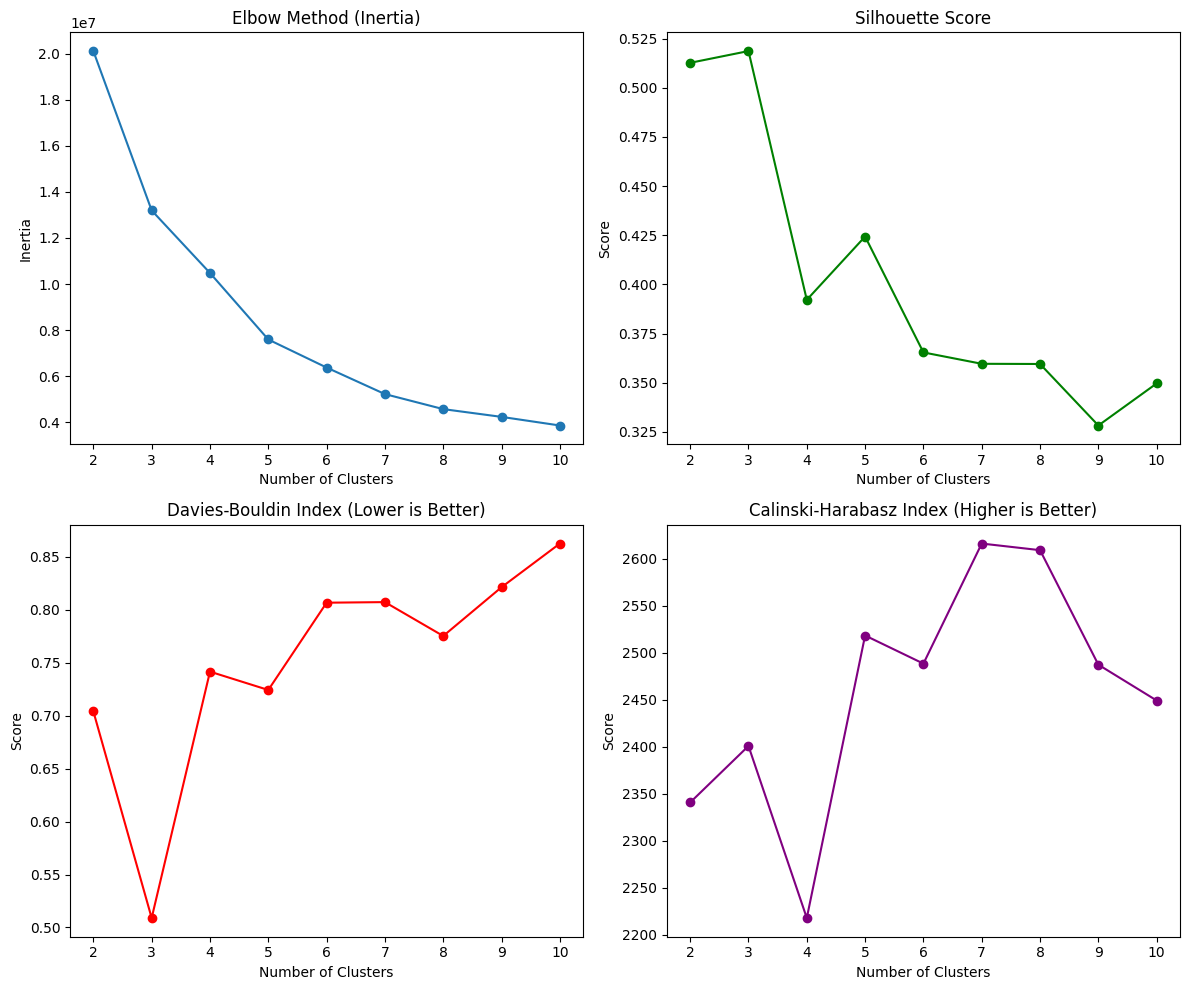

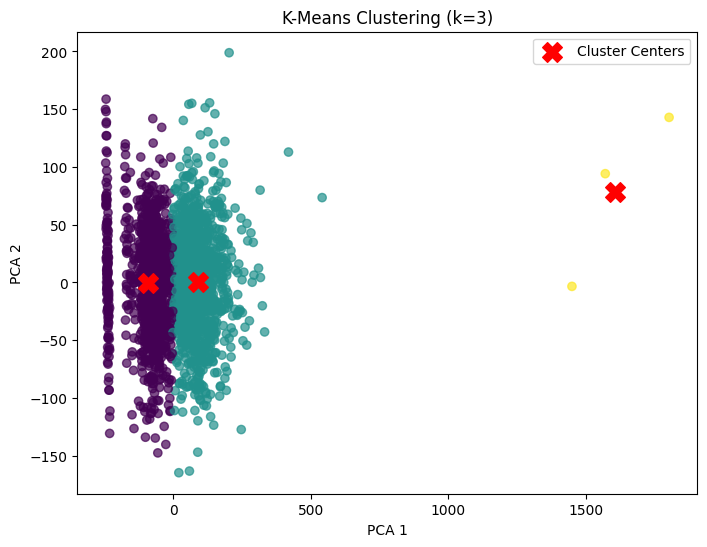

In [59]:

k_values = range(2, 11)  
inertia_values = []
silhouette_values = []
davies_bouldin_values = []
calinski_harabasz_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=34, n_init=10)
    labels = kmeans.fit_predict(data)
    
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(data, labels))
    davies_bouldin_values.append(davies_bouldin_score(data, labels))
    calinski_harabasz_values.append(calinski_harabasz_score(data, labels))

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0, 0].plot(k_values, inertia_values, marker='o')
ax[0, 0].set_title("Elbow Method (Inertia)")
ax[0, 0].set_xlabel("Number of Clusters")
ax[0, 0].set_ylabel("Inertia")

ax[0, 1].plot(k_values, silhouette_values, marker='o', color='g')
ax[0, 1].set_title("Silhouette Score")
ax[0, 1].set_xlabel("Number of Clusters")
ax[0, 1].set_ylabel("Score")

ax[1, 0].plot(k_values, davies_bouldin_values, marker='o', color='r')
ax[1, 0].set_title("Davies-Bouldin Index (Lower is Better)")
ax[1, 0].set_xlabel("Number of Clusters")
ax[1, 0].set_ylabel("Score")

ax[1, 1].plot(k_values, calinski_harabasz_values, marker='o', color='purple')
ax[1, 1].set_title("Calinski-Harabasz Index (Higher is Better)")
ax[1, 1].set_xlabel("Number of Clusters")
ax[1, 1].set_ylabel("Score")

plt.tight_layout()
plt.show()

best_k = k_values[silhouette_values.index(max(silhouette_values))]
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(data)

plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Cluster Centers')
plt.title(f"K-Means Clustering (k={best_k})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()


### DBSCAN

Optimal eps: 43.100
Number of clusters: 2
Number of noise points: 11
Silhouette Score: 0.465
Davies-Bouldin Index: 0.912
Calinski-Harabasz Index: 465.035


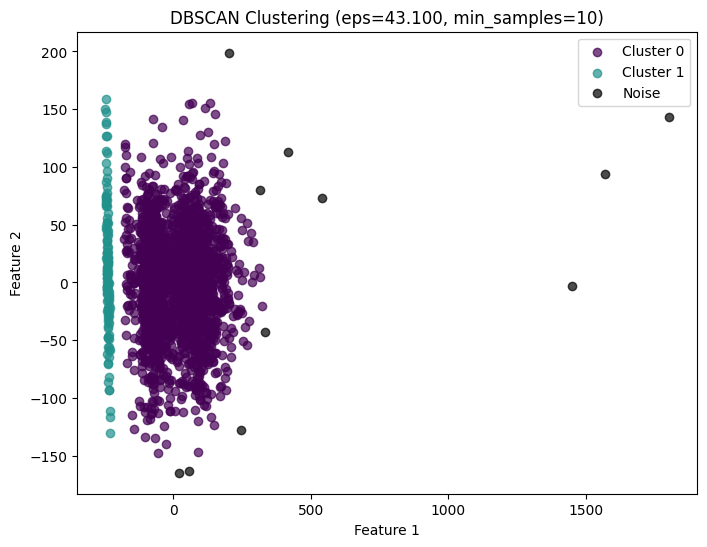

In [60]:
nearest_neighbors = NearestNeighbors(n_neighbors=5)
neighbors = nearest_neighbors.fit(data)
distances, indices = neighbors.kneighbors(data)
distances = np.sort(distances[:, -1])

knee_locator = KneeLocator(range(len(distances)), distances, curve="convex", direction="increasing")
eps_value = distances[knee_locator.knee] * 1.1  
min_samples_value = 10  

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels = dbscan.fit_predict(data)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Optimal eps: {eps_value:.3f}")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

if n_clusters > 1:
    silhouette = silhouette_score(data, labels)
    davies_bouldin = davies_bouldin_score(data, labels)
    calinski_harabasz = calinski_harabasz_score(data, labels)
    
    print(f"Silhouette Score: {silhouette:.3f}")
    print(f"Davies-Bouldin Index: {davies_bouldin:.3f}")
    print(f"Calinski-Harabasz Index: {calinski_harabasz:.3f}")
else:
    print("DBSCAN did not find valid clusters. Try adjusting eps and min_samples.")

plt.figure(figsize=(8, 6))
unique_labels = set(labels)

for label in unique_labels:
    if label == -1:
        color = 'k' 
        label_name = "Noise"
    else:
        color = plt.cm.viridis(label / (n_clusters if n_clusters > 0 else 1))
        label_name = f"Cluster {label}"

    plt.scatter(data[labels == label, 0], data[labels == label, 1], c=[color], label=label_name, alpha=0.7)

plt.title(f"DBSCAN Clustering (eps={eps_value:.3f}, min_samples={min_samples_value})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


### Agglomerative 

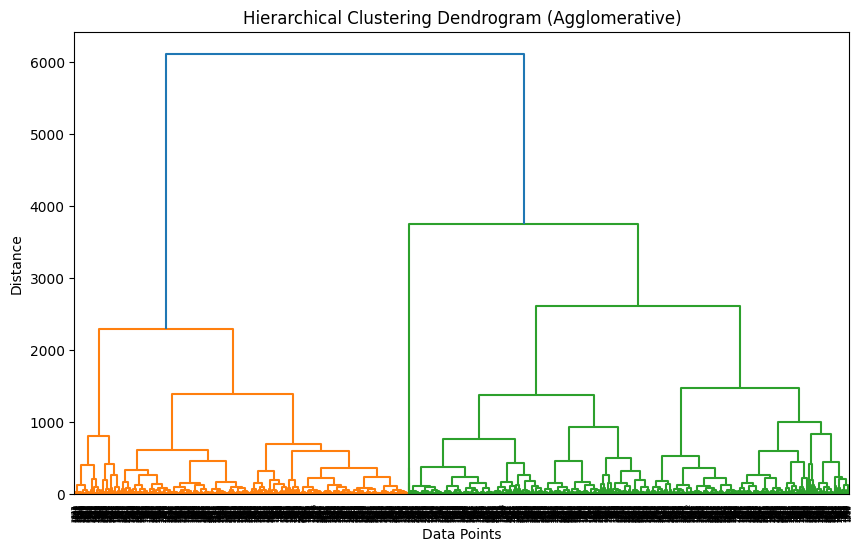

Optimal Number of Clusters (Agglomerative): 3
Silhouette Score: 0.479
Davies-Bouldin Index: 0.536
Calinski-Harabasz Index: 2125.888


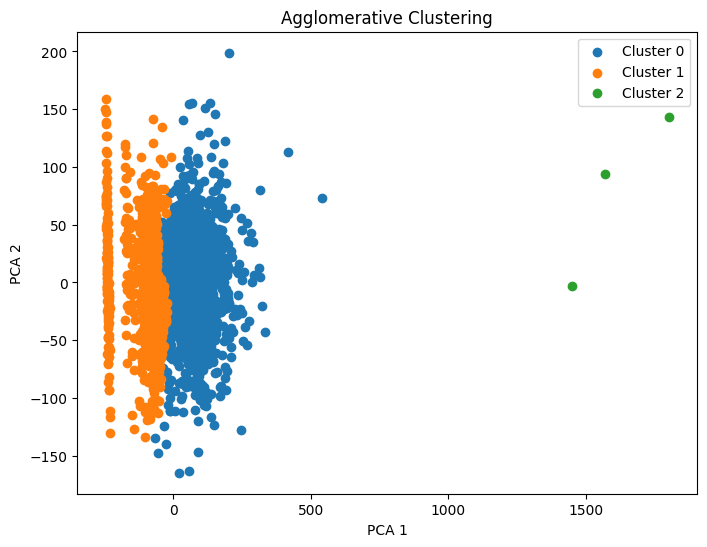

In [61]:
def plot_dendrogram():
    linked = linkage(data, method='ward')
    plt.figure(figsize=(10, 6))
    dendrogram(linked)
    plt.title("Hierarchical Clustering Dendrogram (Agglomerative)")
    plt.xlabel("Data Points")
    plt.ylabel("Distance")
    plt.show()

plot_dendrogram()

best_n_clusters = 2
best_silhouette = -1

for n_clusters in range(2, 10):  
    agglo = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = agglo.fit_predict(data)
    silhouette = silhouette_score(data, labels)
    
    if silhouette > best_silhouette:
        best_silhouette = silhouette
        best_n_clusters = n_clusters

print(f"Optimal Number of Clusters (Agglomerative): {best_n_clusters}")


agglo = AgglomerativeClustering(n_clusters=best_n_clusters, linkage='ward')
labels_agglo = agglo.fit_predict(data)


silhouette = silhouette_score(data, labels_agglo)
davies_bouldin = davies_bouldin_score(data, labels_agglo)
calinski_harabasz = calinski_harabasz_score(data, labels_agglo)

print(f"Silhouette Score: {silhouette:.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.3f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz:.3f}")


plt.figure(figsize=(8, 6))
for label in np.unique(labels_agglo):
    plt.scatter(data[labels_agglo == label, 0], data[labels_agglo == label, 1], label=f"Cluster {label}")

plt.title("Agglomerative Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()
